In [1]:
import pandas as pd

file_path = 'dane/cleaned_data.csv'
df_modeling = pd.read_csv(file_path)
df_modeling.head(20)

,Perfume_ID,Name,Brand,Gender,Rating Value,Rating Count,Clean_Accords,Description,Semantic_Text,url,Main Accords
0,70706,9am,Afnan,for women,3.73,174.0,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...,Perfume: 9am by Afnan. 9am by Afnan is a fragr...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['citrus', 'musky', 'woody', 'aromatic', 'warm..."
1,78611,9am Dive,Afnan,for women and men,4.29,842.0,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...,Perfume: 9am Dive by Afnan. 9am Dive by Afnan ...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'woody', 'green', 'warm spicy', 'ar..."
2,78541,9am pour Femme,Afnan,for women,4.00,68.0,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...,Perfume: 9am pour Femme by Afnan. 9am pour Fem...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'musky', 'amber', 'citrus', 'powder..."
3,78544,9pm pour Femme,Afnan,for women,3.49,63.0,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...,Perfume: 9pm pour Femme by Afnan. 9pm pour Fem...,https://www.fragrantica.com/perfume/Afnan/9pm-...,"['woody', 'aromatic', 'rose', 'fruity', 'powde..."
4,36596,Black Oudh,Al Haramain Perfumes,for women and men,4.12,113.0,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...,Perfume: Black Oudh by Al Haramain Perfumes. B...,https://www.fragrantica.com/perfume/Al-Haramai...,"['woody', 'powdery', 'musky', 'amber', 'patcho..."
5,19864,Bloom,Al Haramain Perfumes,for women,3.73,55.0,"oud, musky, rose, floral, powdery",Bloom by Al Haramain Perfumes is a Amber Flora...,Perfume: Bloom by Al Haramain Perfumes. Bloom ...,https://www.fragrantica.com/perfume/Al-Haramai...,"['oud', 'musky', 'rose', 'floral', 'powdery']"
6,53174,Dhahab,Al Haramain Perfumes,for women and men,4.41,88.0,"caramel, vanilla, sweet, citrus, powdery, musk...",Dhahab by Al Haramain Perfumes is a fragrance ...,Perfume: Dhahab by Al Haramain Perfumes. Dhaha...,https://www.fragrantica.com/perfume/Al-Haramai...,"['caramel', 'vanilla', 'sweet', 'citrus', 'pow..."
7,19810,Haneen,Al Haramain Perfumes,for women and men,3.94,115.0,"rose, oud, powdery, woody, amber",Haneen by Al Haramain Perfumes is a Amber frag...,Perfume: Haneen by Al Haramain Perfumes. Hanee...,https://www.fragrantica.com/perfume/Al-Haramai...,"['rose', 'oud', 'powdery', 'woody', 'amber']"
8,53250,Khulasat Al Oudh,Al Haramain Perfumes,for men,4.27,168.0,"smoky, leather, amber, woody, animalic, sweet,...",Khulasat Al Oudh by Al Haramain Perfumes is a ...,Perfume: Khulasat Al Oudh by Al Haramain Perfu...,https://www.fragrantica.com/perfume/Al-Haramai...,"['smoky', 'leather', 'amber', 'woody', 'animal..."
9,19953,Musk,Al Haramain Perfumes,for women,4.01,105.0,"musky, floral, powdery, fruity, green, sweet, ...",Musk by Al Haramain Perfumes is a Amber Floral...,Perfume: Musk by Al Haramain Perfumes. Musk by...,https://www.fragrantica.com/perfume/Al-Haramai...,"['musky', 'floral', 'powdery', 'fruity', 'gree..."


In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. Zabezpieczenie przed pustymi wartościami
df_modeling['Clean_Accords'] = df_modeling['Clean_Accords'].fillna("")

# 2. Inżynieria cech: Kolumna Top 3 Akordy (idealna dla UI)
def get_top_3(accords_string):
    accords_list = [a.strip() for a in accords_string.split(',')]
    return ", ".join(accords_list[:3])

df_modeling['Top3_Accords'] = df_modeling['Clean_Accords'].apply(get_top_3)

texts = df_modeling['Top3_Accords'].tolist()

print("Generowanie czystych wektorów zapachowych SBERT...")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = model.encode(texts, show_progress_bar=True)
df_modeling['Embeddings'] = list(embeddings)

print("✅ Wektoryzacja zakończona sukcesem!")
display(df_modeling[['Name', 'Brand', 'Top3_Accords']].head())

Generowanie czystych wektorów zapachowych SBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/678 [00:00<?, ?it/s]

✅ Wektoryzacja zakończona sukcesem!


,Name,Brand,Top3_Accords
0,9am,Afnan,"citrus, musky, woody"
1,9am Dive,Afnan,"fruity, woody, green"
2,9am pour Femme,Afnan,"fruity, musky, amber"
3,9pm pour Femme,Afnan,"woody, aromatic, rose"
4,Black Oudh,Al Haramain Perfumes,"woody, powdery, musky"


1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...


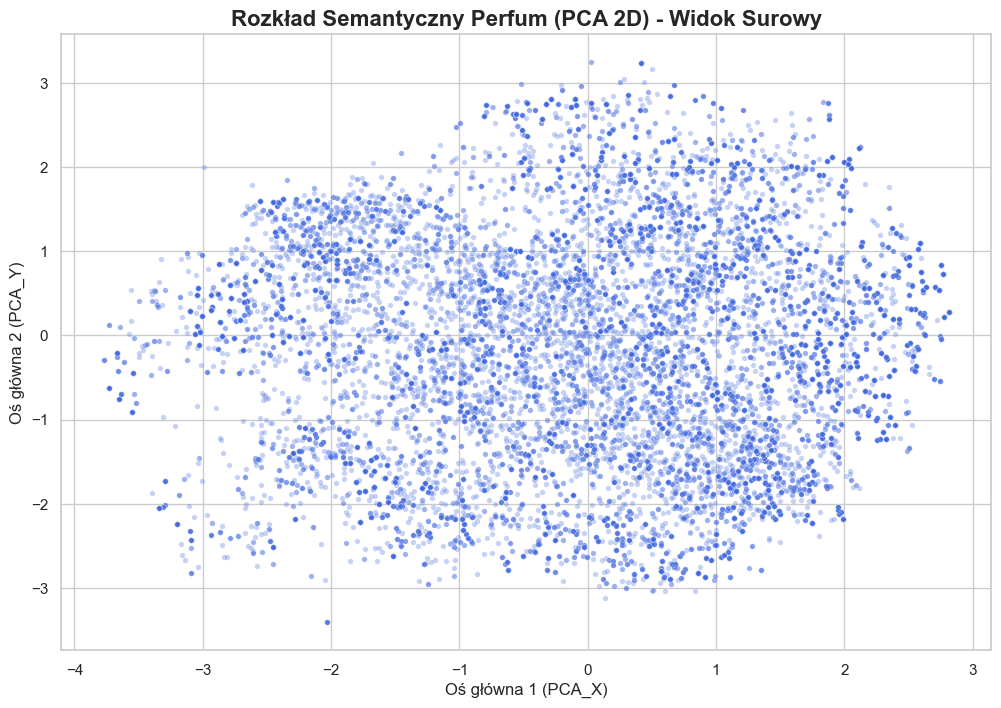

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

X_embeddings = np.array(df_modeling['Embeddings'].tolist())

print("1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_embeddings)

df_modeling['PCA_X'] = X_pca[:, 0]
df_modeling['PCA_Y'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    alpha=0.3, 
    s=15, 
    color='royalblue'
)

plt.title('Rozkład Semantyczny Perfum (PCA 2D) - Widok Surowy', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.show()

Dla K=2 -> Silhouette Score: 0.3680
Dla K=3 -> Silhouette Score: 0.3986
Dla K=4 -> Silhouette Score: 0.3933
Dla K=5 -> Silhouette Score: 0.3886
Dla K=6 -> Silhouette Score: 0.3621
Dla K=7 -> Silhouette Score: 0.4143
Dla K=8 -> Silhouette Score: 0.3832
Dla K=9 -> Silhouette Score: 0.3838
Dla K=10 -> Silhouette Score: 0.3894


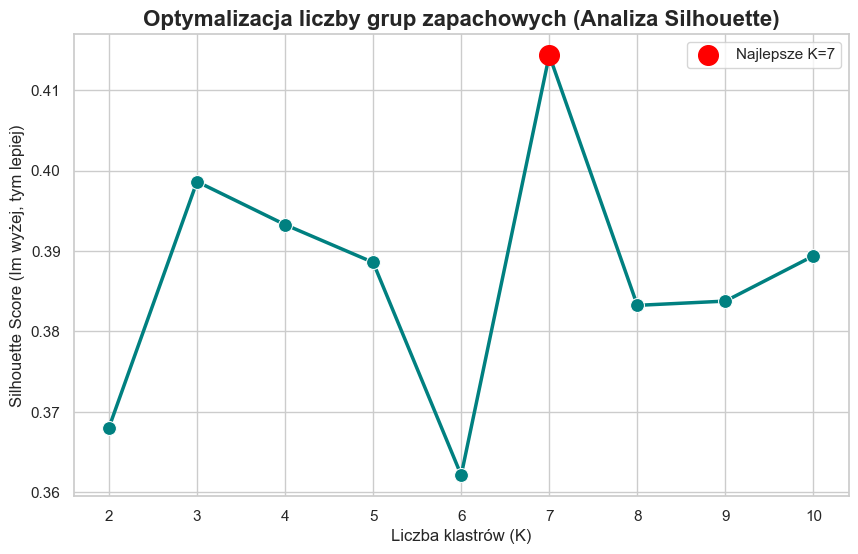


Matematycznie najlepszy podział to K=7 (Wynik: 0.4143)


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    
    cluster_labels = kmeans.fit_predict(df_modeling[['PCA_X', 'PCA_Y']])
    
    score = silhouette_score(df_modeling[['PCA_X', 'PCA_Y']], cluster_labels)
    
    silhouette_scores.append(score)
    print(f"Dla K={k} -> Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(x=k_values, y=silhouette_scores, marker='o', markersize=10, color='teal', linewidth=2.5)

best_k_index = silhouette_scores.index(max(silhouette_scores))
best_k = k_values[best_k_index]
best_score = silhouette_scores[best_k_index]
plt.scatter(best_k, best_score, color='red', s=200, zorder=5, label=f'Najlepsze K={best_k}')

plt.title('Optymalizacja liczby grup zapachowych (Analiza Silhouette)', fontsize=16, fontweight='bold')
plt.xlabel('Liczba klastrów (K)', fontsize=12)
plt.ylabel('Silhouette Score (Im wyżej, tym lepiej)', fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.show()

print(f"\nMatematycznie najlepszy podział to K={best_k} (Wynik: {best_score:.4f})")

Liczba klastrów (grup): 7
Wynik Silhouette Score: 0.4143


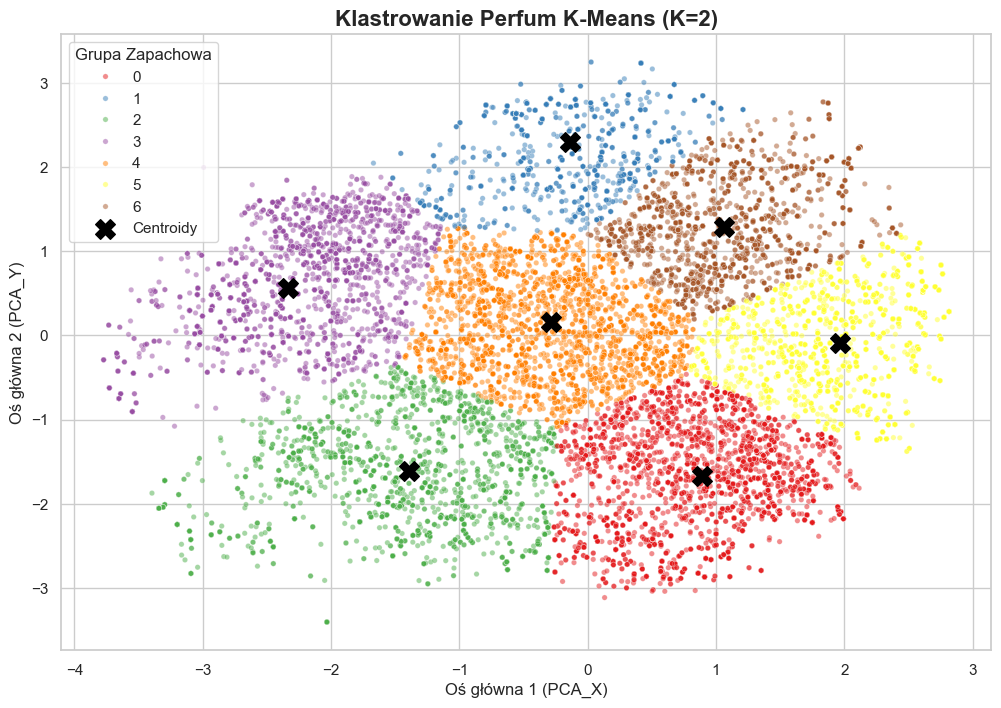

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

num_clusters = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")

df_modeling['Cluster_ID'] = kmeans.fit_predict(df_modeling[['PCA_X', 'PCA_Y']])

sil_score = silhouette_score(df_modeling[['PCA_X', 'PCA_Y']], df_modeling['Cluster_ID'])

print(f"Liczba klastrów (grup): {best_k}")
print(f"Wynik Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    hue=df_modeling['Cluster_ID'], 
    palette='Set1', 
    alpha=0.5, 
    s=15
)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroidy')

plt.title(f'Klastrowanie Perfum K-Means (K={num_clusters})', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.legend(title='Grupa Zapachowa')
plt.show()

In [6]:
import pandas as pd
from collections import Counter

print("--- PROFILOWANIE KLASTRÓW ZAPACHOWYCH ---")

unique_clusters = sorted(df_modeling['Cluster_ID'].unique())

for cluster_num in unique_clusters:
    cluster_data = df_modeling[df_modeling['Cluster_ID'] == cluster_num]['Clean_Accords']
    
    all_accords = []
    for accords_string in cluster_data.dropna():
        accords = [accord.strip().lower() for accord in accords_string.split(',')]
        all_accords.extend(accords)
        
    accord_counts = Counter(all_accords)
    
    top_accords = accord_counts.most_common(5)
    
    print(f"\nKLASTER {cluster_num} (Liczba perfum: {len(cluster_data)})")
    
    tags = [f"{accord} ({count}x)" for accord, count in top_accords]
    print("Dominujące akordy:", ", ".join(tags))

--- PROFILOWANIE KLASTRÓW ZAPACHOWYCH ---

KLASTER 0 (Liczba perfum: 3673)
Dominujące akordy: floral (2679x), woody (2315x), white floral (2237x), powdery (2200x), sweet (1760x)

KLASTER 1 (Liczba perfum: 1707)
Dominujące akordy: citrus (1493x), aromatic (1283x), fresh spicy (1224x), woody (1184x), warm spicy (954x)

KLASTER 2 (Liczba perfum: 2638)
Dominujące akordy: woody (2320x), powdery (1486x), aromatic (1354x), amber (1267x), warm spicy (1247x)

KLASTER 3 (Liczba perfum: 3599)
Dominujące akordy: woody (3002x), warm spicy (2899x), aromatic (2406x), fresh spicy (2176x), amber (1922x)

KLASTER 4 (Liczba perfum: 3479)
Dominujące akordy: woody (2226x), powdery (2167x), sweet (2000x), vanilla (1708x), warm spicy (1519x)

KLASTER 5 (Liczba perfum: 3323)
Dominujące akordy: citrus (2379x), floral (2345x), sweet (2242x), fruity (2199x), white floral (2046x)

KLASTER 6 (Liczba perfum: 3273)
Dominujące akordy: citrus (2314x), sweet (2283x), fruity (2027x), woody (1766x), powdery (1586x)


WEKTORYZACJA TF-IDF
Wygenerowano macierz TF-IDF o wymiarach: 21692 perfum x 81 unikalnych akordów.

OPTYMALIZACJA K-MEANS (SILHOUETTE)
Dla K=2 -> Silhouette Score: 0.0598
Dla K=3 -> Silhouette Score: 0.0572
Dla K=4 -> Silhouette Score: 0.0550
Dla K=5 -> Silhouette Score: 0.0552
Dla K=6 -> Silhouette Score: 0.0569
Dla K=7 -> Silhouette Score: 0.0570
Dla K=8 -> Silhouette Score: 0.0631
Dla K=9 -> Silhouette Score: 0.0701
Dla K=10 -> Silhouette Score: 0.0717

Wybrano K=10 jako optymalną liczbę klastrów zapachowych.

TRENOWANIE DOCELOWE I REDUKCJA PCA

PROFILE ZAPACHOWE KLASTRÓW
KLASTER 0: tropical (1240x), fruity (1046x), sweet (1015x), floral (735x), fresh (657x)
KLASTER 1: aromatic (2950x), fresh spicy (2757x), citrus (2745x), woody (2571x), green (1951x)
KLASTER 2: sweet (4000x), powdery (3249x), floral (2944x), fruity (2868x), white floral (2801x)
KLASTER 3: aquatic (1582x), fresh (1038x), woody (994x), ozonic (961x), floral (922x)
KLASTER 4: iris (1352x), powdery (1323x), woody (1052

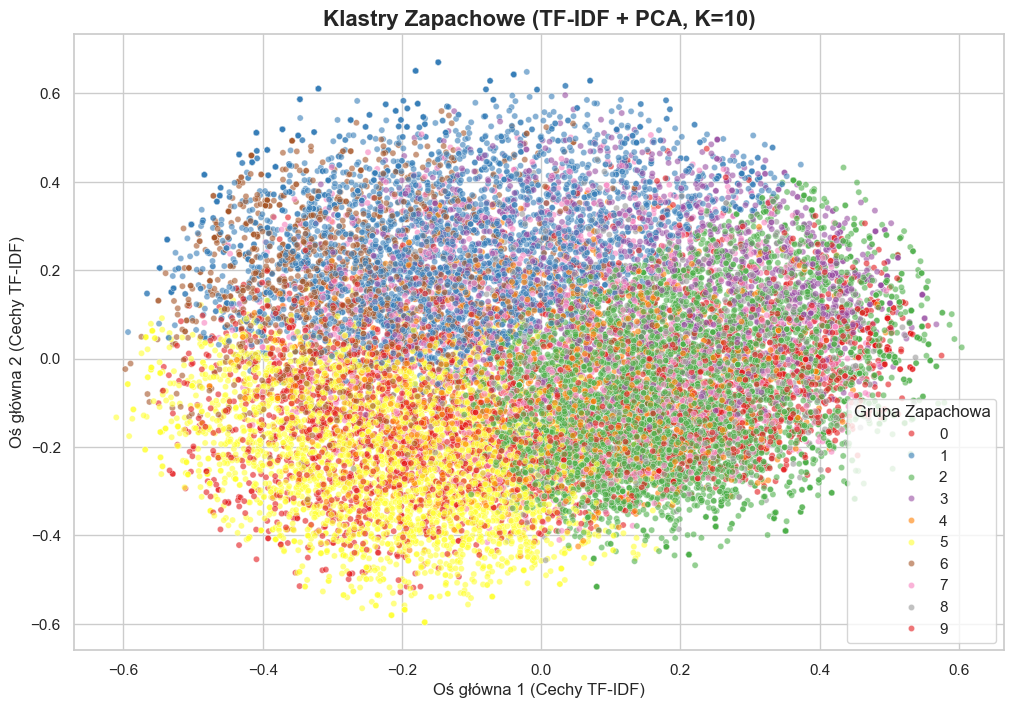

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

print("WEKTORYZACJA TF-IDF")
def accord_tokenizer(text):
    return [tag.strip() for tag in text.split(',') if tag.strip()]

tfidf_vectorizer = TfidfVectorizer(tokenizer=accord_tokenizer, lowercase=True)
X_tfidf = tfidf_vectorizer.fit_transform(df_modeling['Clean_Accords'].fillna(""))
X_dense = X_tfidf.toarray()

print(f"Wygenerowano macierz TF-IDF o wymiarach: {X_dense.shape[0]} perfum x {X_dense.shape[1]} unikalnych akordów.")

print("\nOPTYMALIZACJA K-MEANS (SILHOUETTE)")
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_temp = kmeans_temp.fit_predict(X_dense)
    score = silhouette_score(X_dense, labels_temp)
    silhouette_scores.append(score)
    print(f"Dla K={k} -> Silhouette Score: {score:.4f}")

best_k_idx = silhouette_scores.index(max(silhouette_scores))
best_k = k_values[best_k_idx]
print(f"\nWybrano K={best_k} jako optymalną liczbę klastrów zapachowych.")

print("\nTRENOWANIE DOCELOWE I REDUKCJA PCA")
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df_modeling['Cluster_ID'] = final_kmeans.fit_predict(X_dense)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)
df_modeling['PCA_X'] = X_pca[:, 0]
df_modeling['PCA_Y'] = X_pca[:, 1]

print("\nPROFILE ZAPACHOWE KLASTRÓW")
unique_clusters = sorted(df_modeling['Cluster_ID'].unique())
for cluster_num in unique_clusters:
    cluster_data = df_modeling[df_modeling['Cluster_ID'] == cluster_num]['Clean_Accords']
    all_accords = []
    for accords_string in cluster_data.dropna():
        accords = [a.strip().lower() for a in accords_string.split(',')]
        all_accords.extend(accords)
    
    top_accords = Counter(all_accords).most_common(5)
    tags = [f"{accord} ({count}x)" for accord, count in top_accords]
    print(f"KLASTER {cluster_num}: {', '.join(tags)}")

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    hue=df_modeling['Cluster_ID'], 
    palette='Set1', 
    alpha=0.6, 
    s=20
)
plt.title(f'Klastry Zapachowe (TF-IDF + PCA, K={best_k})', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (Cechy TF-IDF)')
plt.ylabel('Oś główna 2 (Cechy TF-IDF)')
plt.legend(title='Grupa Zapachowa')
plt.show()

In [8]:
import pandas as pd

cluster_names = {
    0: "Owocowo-Tropikalne",            # tropical, fruity, sweet
    1: "Świeżo-aromatyczne",            # aromatic, fresh spicy, green
    2: "Słodko-Kwiatowe",               # sweet, powdery, floral, white floral
    3: "Morsko-ozonowe",                # aquatic, fresh, ozonic
    4: "Irysowe",                       # iris, earthy, powdery
    5: "Orientalno-bursztynowe",        # warm spicy, amber, balsamic
    6: "Fougère",                       # lavender, aromatic
    7: "Drzewno-słodkie",               # soft spicy, woody
    8: "Kwiatowo-Pudrowe",              # violet, powdery, floral
    9: "Skórzane"                       # leather, animalic, warm spicy
}

df_modeling['Cluster_Name'] = df_modeling['Cluster_ID'].map(cluster_names)

In [9]:
df_modeling.head()

,Perfume_ID,Name,Brand,Gender,Rating Value,Rating Count,Clean_Accords,Description,Semantic_Text,url,Main Accords,Top3_Accords,Embeddings,PCA_X,PCA_Y,Cluster_ID,Cluster_Name
0,70706,9am,Afnan,for women,3.73,174.0,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...,Perfume: 9am by Afnan. 9am by Afnan is a fragr...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['citrus', 'musky', 'woody', 'aromatic', 'warm...","citrus, musky, woody","[0.0021611142, -0.28886947, 0.2616395, 0.53324...",-0.187999,0.164371,6,Fougère
1,78611,9am Dive,Afnan,for women and men,4.29,842.0,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...,Perfume: 9am Dive by Afnan. 9am Dive by Afnan ...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'woody', 'green', 'warm spicy', 'ar...","fruity, woody, green","[0.3655266, -0.33164626, 0.4240782, 0.05030762...",-0.167395,0.328380,7,Drzewno-słodkie
2,78541,9am pour Femme,Afnan,for women,4.00,68.0,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...,Perfume: 9am pour Femme by Afnan. 9am pour Fem...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'musky', 'amber', 'citrus', 'powder...","fruity, musky, amber","[-0.06578791, -0.37495762, 0.39220583, 0.33495...",0.135875,-0.197764,7,Drzewno-słodkie
3,78544,9pm pour Femme,Afnan,for women,3.49,63.0,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...,Perfume: 9pm pour Femme by Afnan. 9pm pour Fem...,https://www.fragrantica.com/perfume/Afnan/9pm-...,"['woody', 'aromatic', 'rose', 'fruity', 'powde...","woody, aromatic, rose","[-0.064414494, 0.07051751, 0.17741239, 0.57105...",0.144237,0.065366,8,Kwiatowo-Pudrowe
4,36596,Black Oudh,Al Haramain Perfumes,for women and men,4.12,113.0,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...,Perfume: Black Oudh by Al Haramain Perfumes. B...,https://www.fragrantica.com/perfume/Al-Haramai...,"['woody', 'powdery', 'musky', 'amber', 'patcho...","woody, powdery, musky","[0.039781015, -0.28533533, 0.25941008, 0.24064...",-0.235638,-0.350204,5,Orientalno-bursztynowe


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

X = np.array(df_modeling['Embeddings'].tolist())
y = df_modeling['Gender'].fillna('unisex')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dane gotowe: {len(X_train)} rekordów do nauki, {len(X_test)} do weryfikacji.")

svm_classifier = LinearSVC(random_state=42, max_iter=2000)
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

standard_accuracy = accuracy_score(y_test, y_pred)
print(f"Standardowa dokładność (bez podziału na typ błędu): {standard_accuracy:.2%}")

def calculate_business_accuracy(y_true, y_predict):
    score = 0.0
    total = len(y_true)
    
    for true, pred in zip(y_true, y_predict):
        true = str(true).strip().lower()
        pred = str(pred).strip().lower()
        
        if true == pred:
            score += 1.0  
        elif (true == 'for men' and pred == 'for women') or (true == 'for women' and pred == 'for men'):
            score += 0.0  
        else:
            score += 0.5  
            
    return score / total

biz_accuracy = calculate_business_accuracy(y_test, y_pred)
print(f"Dokładność ważona: {biz_accuracy:.2%}\n")

print("Szczegółowy raport klasyfikacji:")
print(classification_report(y_test, y_pred))

test_indices = y_test.index
df_test = df_modeling.loc[test_indices].copy()
df_test['Przewidziana_Plec'] = y_pred

sample_predictions = df_test.sample(10, random_state=None)

for index, row in sample_predictions.iterrows():
    name = row['Name']
    brand = row['Brand']
    
    actual_gender = str(row['Gender']).strip().lower()
    predicted_gender = str(row['Przewidziana_Plec']).strip().lower()
    
    if actual_gender == predicted_gender:
        status = "TRAFIENIE"
    elif (actual_gender == 'for men' and predicted_gender == 'for women') or (actual_gender == 'for women' and predicted_gender == 'for men'):
        status = "BŁĄD KRYTYCZNY"
    else:
        status = "MIĘKKI BŁĄD"
        
    print(f"\n{status}: {name} (Marka: {brand})")
    print(f"   Marketing (Prawda): {actual_gender}")
    print(f"   Model SVM uważa:    {predicted_gender}")
    
    accords = row.get('Top3_Accords', 'Brak akordów')
    print(f"   Na podstawie nut:   {accords}")

Dane gotowe: 17353 rekordów do nauki, 4339 do weryfikacji.
Standardowa dokładność (bez podziału na typ błędu): 63.75%
Dokładność ważona: 79.80%

Szczegółowy raport klasyfikacji:
                   precision    recall  f1-score   support

          for men       0.57      0.52      0.55       759
        for women       0.69      0.80      0.74      1981
for women and men       0.58      0.49      0.53      1599

         accuracy                           0.64      4339
        macro avg       0.61      0.60      0.61      4339
     weighted avg       0.63      0.64      0.63      4339


TRAFIENIE: Eau Sucrée Salée (Vanille + Fleur de Sel) (Marka: Sephora)
   Marketing (Prawda): for women and men
   Model SVM uważa:    for women and men
   Na podstawie nut:   vanilla, salty, marine

TRAFIENIE: Quasar Rush O Boticário (Marka: O Boticario)
   Marketing (Prawda): for men
   Model SVM uważa:    for men
   Na podstawie nut:   aromatic, aquatic, citrus

TRAFIENIE: Zara Night Pour Homme IV (M

In [11]:
import pandas as pd

accords_series = df_modeling['Clean_Accords'].fillna("")

cleaned_lists = accords_series.apply(
    lambda x: [accord.strip().lower() for accord in x.split(',') if accord.strip()]
)

exploded_accords = cleaned_lists.explode()

accord_counts = exploded_accords.value_counts()

print(f"Wykryto dokładnie {len(accord_counts)} unikalnych akordów.\n")

for accord, count in accord_counts.items():
    print(f"{accord}, ")

Wykryto dokładnie 81 unikalnych akordów.

woody, 
powdery, 
sweet, 
citrus, 
aromatic, 
floral, 
warm spicy, 
fruity, 
fresh spicy, 
amber, 
musky, 
white floral, 
vanilla, 
fresh, 
green, 
rose, 
earthy, 
balsamic, 
patchouli, 
animalic, 
soft spicy, 
leather, 
aquatic, 
iris, 
violet, 
herbal, 
yellow floral, 
lavender, 
tropical, 
oud, 
smoky, 
ozonic, 
mossy, 
lactonic, 
cinnamon, 
tuberose, 
nutty, 
tobacco, 
marine, 
caramel, 
almond, 
honey, 
coconut, 
aldehydic, 
salty, 
metallic, 
cacao, 
coffee, 
anis, 
chocolate, 
cherry, 
rum, 
conifer, 
soapy, 
sour, 
mineral, 
camphor, 
whiskey, 
savory, 
beeswax, 
champagne, 
bitter, 
cannabis, 
sand, 
terpenic, 
wine, 
alcohol, 
vodka, 
coca-cola, 
vinyl, 
clay, 
asphault, 
oily, 
gasoline, 
hot iron, 
tennis ball, 
plastic, 
industrial glue, 
brown scotch tape, 
foresty, 
sake, 


In [12]:
import pandas as pd
import os

mood_mapping = {
    "Nastrój_PL": [
        "do biura, biznesowe, profesjonalne, formalne, spotkanie, opanowany",
        "romantyczna randka, zmysłowy, uwodzicielski, na wieczór, intymny",
        "klubowa noc, impreza, głośny, wyrazisty, pewność siebie",
        "ślub, wesele, elegancki, radosny, świetlisty, uroczystość",
        "na siłownię, sportowe, trening, odświeżający, energia, dynamika",
        "gorące lato, upał, plaża, wakacje, orzeźwiający, słońce",
        "mroźna zima, śnieg, mróz, otulający, rozgrzewający, przy kominku",
        "deszczowy jesienny dzień, melancholia, opadłe liście, spokój, nostalgia",
        "wiosenny poranek, przebudzenie, zieleń, kwitnące kwiaty, rześki",
        "mroczny, tajemniczy, intrygujący, niepokojący, gotycki, niszowy",
        "czysty, sterylny, pranie, świeżo wyprany, biała koszula, mydlany",
        "elegancki, old-money, luksusowy, klasyczny, ponadczasowy, bogaty",
        "słodki, przytulny, gourmand, smakowity, deser, jadalny",
        "męski, surowy, barbershop, po goleniu, klasycznie męski, fougere",
        "femme fatale, uwodzicielka, dominująca, niebezpieczna, hipnotyzująca",
        "spacer po lesie, natura, drzewa, dzika przyroda, iglaste, żywiczne",
        "kawiarnia, kawa, relaks, czytanie książki, ciepły napój, pobudzający",
        "buntowniczy, skórzana kurtka, motocykl, rock, odważny, dymny",
        "speakeasy, alkohol, bar, cygara, jazz, elegancki wieczór",
        "cyberpunk, industrialny, miasto nocą, sztuczny, neon, futurystyczny",
        "surowe drewno, tartak, świeża deska, rzemieślnik, stolarnia, wióry",
        "luksusowe kosmetyki, puderniczka, szminka, miękki, buduar, makijaż",
        "landrynki, wata cukrowa, dziewczęcy, beztroski, owocowe cukierki",
        "wyciśnięty sok, cytrusowy, poranny prysznic, rześki, energetyzujący, cierpki",
        "kwiaciarnia, bukiet, cięte kwiaty, ogród botaniczny, kwitnący, nektar",
        "orientalny bazar, przyprawy, bogaty, gęsty, arabski, luksusowy wschód",
        "ziołowy napar, apteczny, szałwia, rześkie zioła, naturalny, uzdrawiający",
        "stara biblioteka, antykwariat, pożółkły papier, kurz, stare książki, drewniane regały",
        "naga skóra, po kąpieli, intymny, delikatny, bliskoskórny, naturalny zapach ciała",
        "egzotyczne owoce, koktajl, plażowy drink, radosny, soczysty, słoneczny",
        "złota godzina, rozgrzana słońcem skóra, świetlisty, miękki szal, kojący, bogaty",
        "pieprzny, chłodne przyprawy, iskrzący, świdrujący, dynamiczny, ostry",
        "poranna rosa, skoszona trawa, łodygi, soczysta zieleń, mokry, wiosenny",
        "odurzające kwiaty, gęsty nektar, pyłek, upojny, zmysłowe kwiaty, duszny",
        "wilgotna ziemia, piwnica, deszcz na betonie, surowy, mroczny las, paczula"
    ],
    "Akordy_EN": [
        "woody, aromatic, citrus, fresh spicy, musky",
        "vanilla, amber, musky, sweet, white floral, rose",
        "sweet, warm spicy, amber, vanilla, leather, rum",
        "white floral, floral, powdery, musky, citrus, aldehydic",
        "citrus, fresh, aquatic, ozonic, marine, fresh spicy",
        "citrus, coconut, tropical, marine, salty, sand",
        "warm spicy, amber, woody, cinnamon, vanilla, smoky",
        "earthy, mossy, woody, patchouli, ozonic, mineral",
        "green, floral, fresh, yellow floral, herbal, powdery",
        "oud, smoky, patchouli, earthy, balsamic, animalic",
        "aldehydic, soapy, musky, powdery, fresh, white floral",
        "iris, powdery, woody, leather, aromatic, earthy",
        "caramel, vanilla, chocolate, sweet, lactonic, almond, honey",
        "lavender, aromatic, woody, mossy, fresh spicy, herbal",
        "tuberose, amber, animalic, white floral, warm spicy, patchouli",
        "conifer, woody, foresty, mossy, earthy, camphor",
        "coffee, sweet, warm spicy, vanilla, cacao, lactonic",
        "leather, smoky, animalic, tobacco, woody, asphault",
        "whiskey, tobacco, woody, sweet, rum, amber",
        "metallic, vinyl, plastic, mineral, gasoline, hot iron",
        "woody, aromatic, fresh, earthy, balsamic",
        "powdery, musky, iris, violet, floral",
        "sweet, fruity, vanilla, caramel, powdery",
        "citrus, fresh, green, fresh spicy, aromatic",
        "floral, white floral, rose, green, fresh",
        "warm spicy, amber, woody, sweet, balsamic",
        "aromatic, herbal, fresh spicy, green, fresh",
        "woody, powdery, vanilla, leather, earthy",
        "musky, powdery, fresh, floral, animalic",
        "fruity, tropical, citrus, sweet, fresh",
        "amber, vanilla, sweet, warm spicy, musky",
        "fresh spicy, woody, citrus, aromatic, earthy",
        "green, fresh, floral, aquatic, ozonic",
        "white floral, sweet, yellow floral, fruity, tuberose",
        "patchouli, earthy, woody, mossy, mineral"
    ]
}

df_mood_matrix = pd.DataFrame(mood_mapping)

print("Podgląd struktury przed zapisem:")
display(df_mood_matrix.head(3))

output_dir = 'modele'
os.makedirs(output_dir, exist_ok=True) 

matrix_path = os.path.join(output_dir, 'mood_matrix_bridge.pkl')
df_mood_matrix.to_pickle(matrix_path)

Podgląd struktury przed zapisem:


,Nastrój_PL,Akordy_EN
0,"do biura, biznesowe, profesjonalne, formalne, ...","woody, aromatic, citrus, fresh spicy, musky"
1,"romantyczna randka, zmysłowy, uwodzicielski, n...","vanilla, amber, musky, sweet, white floral, rose"
2,"klubowa noc, impreza, głośny, wyrazisty, pewno...","sweet, warm spicy, amber, vanilla, leather, rum"


In [13]:
import joblib
import os

output_dir = 'modele'
os.makedirs(output_dir, exist_ok=True)

db_path = os.path.join(output_dir, 'final_perfume_database.pkl')
df_modeling.to_pickle(db_path)
print(f"Baza danych zapisana: {db_path}")

tfidf_path = os.path.join(output_dir, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, tfidf_path)
print(f"Model TF-IDF zapisany: {tfidf_path}")

svm_path = os.path.join(output_dir, 'svm_classifier.joblib')
joblib.dump(svm_classifier, svm_path)
print(f"Model SVM zapisany: {svm_path}")

Baza danych zapisana: modele\final_perfume_database.pkl
Model TF-IDF zapisany: modele\tfidf_vectorizer.joblib
Model SVM zapisany: modele\svm_classifier.joblib
